# Predictive Coding (Simple)

Minimal notebook setup for exploring predictive coding with NumPy, PyTorch, and torchvision.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import math

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch: {torch.__version__}")
print(f"NumPy: {np.__version__}")

Using device: cpu
PyTorch: 2.13.0
NumPy: 2.5.2


dataset/input variables

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

input_data = datasets.MNIST(root='./data', train=True, transform=transform, download=True)

Training Loop

In [4]:
def train_loop(I, U, r, f, f_prime, alpha, lambda_u, lr_r, lr_U, sigma_2, num_epochs_outer, num_epochs_inner, num_layers):
    I = I.reshape(-1, 1).float()
    e = [None] * num_layers
    for out_epoch in range(num_epochs_outer):
        for in_epoch in range(num_epochs_inner):
            e[0] = I - f(U[0] @ r[0])
            for i in range(1, num_layers):
                e[i] = r[i - 1] - f(U[i] @ r[i])
            for i in range(num_layers):
                dr = (1.0 / sigma_2) * U[i].T @ (f_prime(U[i] @ r[i]) * e[i]) - alpha * r[i]
                if i < num_layers - 1:
                    dr = dr - (1.0 / sigma_2) * e[i + 1]
                r[i] = r[i] + lr_r * dr

        e[0] = I - f(U[0] @ r[0])
        for j in range(1, num_layers):
            e[j] = r[j - 1] - f(U[j] @ r[j])
        for j in range(num_layers):
            du = (1.0 / sigma_2) * (f_prime(U[j] @ r[j]) * e[j]) @ r[j].T - lambda_u * U[j]
            U[j] = U[j] + lr_U * du

    return U, r


validation


In [5]:
def validate(I, U, r, num_layers, f):
    I = I.reshape(-1, 1).float()
    h = r[num_layers - 1]
    for i in range(num_layers - 1, 0, -1):
        h = f(U[i] @ h)
    I_hat = f(U[0] @ h)
    mse_loss = torch.mean((I - I_hat) ** 2)
    return mse_loss, I_hat


In [6]:
def get_patches(image, num_patches):
    grid_size = int(math.sqrt(num_patches))

    assert (
        grid_size**2 == num_patches
    ), f"num_patches ({num_patches}) must be a perfect square!"
    assert 28 % grid_size == 0, (
        f"28 must be divisible by grid_size ({grid_size})!"
    )

    patch_size = 28 // grid_size
    size = 0

    if image.ndim == 3:
        C = image.shape[0]
        patches = image.unfold(1, patch_size, patch_size).unfold(
            2, patch_size, patch_size
        )
        patches = patches.permute(1, 2, 0, 3, 4).reshape(
            num_patches, C * patch_size * patch_size
        )
        size = num_patches * C * patch_size * patch_size
    else:
        patches = image.unfold(0, patch_size, patch_size).unfold(
            1, patch_size, patch_size
        )
        patches = patches.reshape(num_patches, patch_size * patch_size)
        size = num_patches * patch_size * patch_size

    return patches, size

In [7]:
def make_variables(image, initial_r_size=512, k1_per_patch=32, num_layers=4, num_patches=16):
    I, size = get_patches(image.float(), num_patches)
    I = I.reshape(-1, 1)
    k_step_size = (initial_r_size - k1_per_patch) // (num_layers - 1)
    k = [k1_per_patch * num_patches]
    for _ in range(num_layers - 1):
        k.append(k[-1] - k_step_size)

    r = []
    for i in range(num_layers):
        r.append(torch.randn(k[i], 1) * 0.1)

    U = [torch.randn(size, k[0]) * 0.1]
    for i in range(num_layers - 1):
        U.append(torch.randn(k[i], k[i + 1]) * 0.1)

    return I, k, r, U, size



test it

In [8]:
def test(I, U, r, f, f_prime, num_epochs_inner, num_layers, sigma_2, alpha, lr_r):
    e = [None] * num_layers
    for in_epoch in range(num_epochs_inner):
        e[0] = I - f(U[0] @ r[0])
        for i in range(1, num_layers):
            e[i] = r[i - 1] - f(U[i] @ r[i])
        for i in range(num_layers):
            dr = (1.0 / sigma_2) * U[i].T @ (f_prime(U[i] @ r[i]) * e[i]) - alpha * r[i]
            if i < num_layers - 1:
                dr = dr - (1.0 / sigma_2) * e[i + 1]
            r[i] = r[i] + lr_r * dr
    return U, r

        


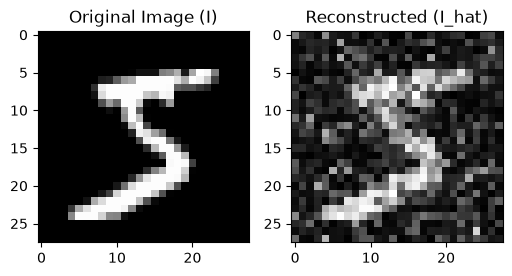

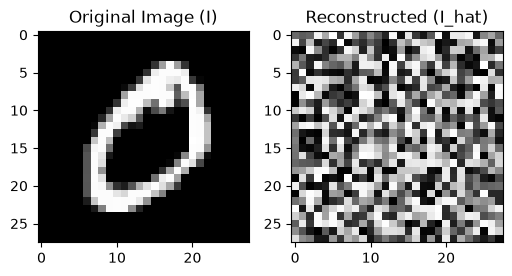

In [13]:
def fold_patches(x, num_patches=16):
    grid = int(math.sqrt(num_patches))
    ps = 28 // grid
    x = x.reshape(grid, grid, ps, ps)
    return x.permute(0, 2, 1, 3).reshape(28, 28)

def main():
    image_one = input_data[0][0]
    image_two = input_data[1][0]

    alpha = 0.01
    lambda_u = 0.005
    lr_r = 0.01
    lr_U = 0.005
    sigma_2 = 1.0
    num_layers = 4
    num_patches = 49

    I_one, k, r, U, size = make_variables(image_one, num_layers=num_layers, num_patches=num_patches)

    f = torch.sigmoid
    f_prime = lambda x: 1 - torch.sigmoid(x) ** 2

    num_epochs_inner = 50
    num_epochs_outer = 10

    U, r = train_loop(I_one, U, r, f, f_prime, alpha, lambda_u, lr_r, lr_U, sigma_2, num_epochs_outer, num_epochs_inner, num_layers)
    mse_loss, I_hat = validate(I_one, U, r, num_layers, f)
    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
    axes[0].imshow(fold_patches(I_one, num_patches).detach().numpy(), cmap="gray")
    axes[0].set_title("Original Image (I)")

    axes[1].imshow(fold_patches(I_hat, num_patches).detach().numpy(), cmap="gray")
    axes[1].set_title("Reconstructed (I_hat)")
    plt.show()

    I_two, k, r, U, size = make_variables(image_two, num_layers=num_layers, num_patches=num_patches)
    mse_loss, I_hat = validate(I_two, U, r, num_layers, f)
    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
    axes[0].imshow(fold_patches(I_two, num_patches).detach().numpy(), cmap="gray")
    axes[0].set_title("Original Image (I)")

    axes[1].imshow(fold_patches(I_hat, num_patches).detach().numpy(), cmap="gray")
    axes[1].set_title("Reconstructed (I_hat)")
    plt.show()
if __name__ == "__main__":
    main()
